# Task 2 : Sentiment Analysis using NLP Pipeline & ML Models
# Name : Mithilesh Kolhapurkar

In [17]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

In [3]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## DATA UNDERSTANDING

In [18]:
df.shape

(50000, 3)

In [19]:
df['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [20]:
df['review'].sample(5)

10172    This was a great book and the possibilities fo...
17457    'Hitch' is a nice surprise: A romantic comedy ...
27131    I decided to watch this ultra-low budget film ...
43090    I guess by the time I saw this episode, I had ...
1309     Halloween 666 (1995) The producer's cut review...
Name: review, dtype: object

## PREPROCESSING FUNCTION

In [21]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"\S+@\S+", "", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]
    tokens = [stemmer.stem(w) for w in tokens]
    return " ".join(tokens)

In [22]:
df['clean_text'] = df['review'].apply(preprocess)
df[['review','clean_text']].head()

,review,clean_text
0,One of the other reviewers has mentioned that ...,one review mention watch oz episod youll hook ...
1,A wonderful little production. <br /><br />The...,wonder littl product br br film techniqu unass...
2,I thought this was a wonderful way to spend ti...,thought wonder way spend time hot summer weeke...
3,Basically there's a family where a little boy ...,basic there famili littl boy jake think there ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei love time money visual stun film...


In [23]:
X = df['clean_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## FEATURE ENGINEERING

In [25]:
bow = CountVectorizer(max_features=5000)

X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

In [26]:
tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

## MODEL BUILDING

In [27]:
lr = LogisticRegression(max_iter=200)
lr.fit(X_train_tfidf, y_train)
y_pred_lr = lr.predict(X_test_tfidf)

In [28]:
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
y_pred_nb = nb.predict(X_test_tfidf)

In [29]:
dt = DecisionTreeClassifier()
dt.fit(X_train_bow, y_train)
y_pred_dt = dt.predict(X_test_bow)

## EVALUATION

In [30]:
def evaluate(y_true, y_pred):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, average='weighted'),
        recall_score(y_true, y_pred, average='weighted'),
        f1_score(y_true, y_pred, average='weighted')
    ]

results = pd.DataFrame({
    "Logistic Regression": evaluate(y_test, y_pred_lr),
    "Naive Bayes": evaluate(y_test, y_pred_nb),
    "Decision Tree": evaluate(y_test, y_pred_dt)
}, index=["Accuracy","Precision","Recall","F1"])

results

,Logistic Regression,Naive Bayes,Decision Tree
Accuracy,0.884600,0.846300,0.718500
Precision,0.884947,0.846329,0.718676
Recall,0.884600,0.846300,0.718500
F1,0.884558,0.846289,0.718486


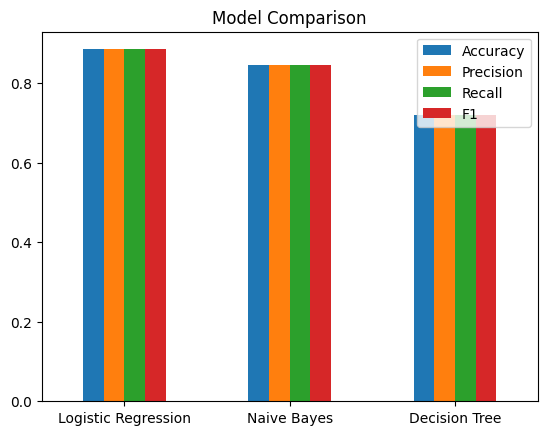

In [31]:
results.T.plot(kind='bar')
plt.title("Model Comparison")
plt.xticks(rotation=0)
plt.show()

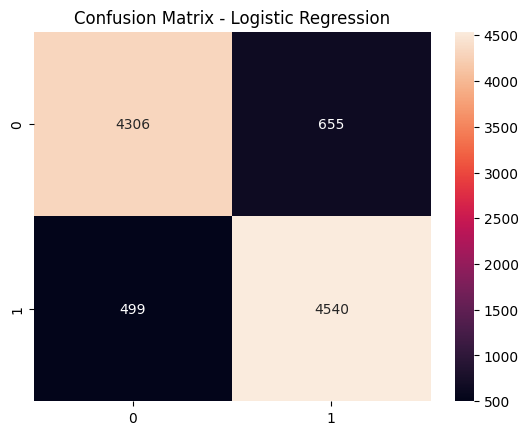

In [32]:
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [33]:
sample = ["This movie was absolutely amazing and fantastic"]

clean_sample = [preprocess(x) for x in sample]
vec_sample = tfidf.transform(clean_sample)

lr.predict(vec_sample)

array(['positive'], dtype=object)

In [34]:
def full_pipeline(text_list):
    clean = [preprocess(x) for x in text_list]
    vec = tfidf.transform(clean)
    preds = lr.predict(vec)
    return preds

full_pipeline(["I love this movie", "Worst film ever"])

array(['positive', 'negative'], dtype=object)